<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Covarite_Export_Sewanee_Pixel_FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

https://lpdaac.usgs.gov/documents/980/gedi_l2b_dictionary_P003_v2.html

# Setup

In [1]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.6/639.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 106.3 MB/s eta 0:00:00


In [2]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00


In [3]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [4]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'data',
    'models',
    'scripts',
    'notebooks',
    'config',
    'results'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")


Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results


In [6]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project


In [7]:

s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
# GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
# GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
# Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
# Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
Map.addLayer(HLS_2021, {}, 'HLS_2021')
Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')

stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)

Map.addLayer(stacked, {}, 'stacked');

Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

#Spatial Autocorreltion Block

In [8]:
# import ee

# # ee.Authenticate()
# ee.Initialize()

# === PARAMETERS ===
subsample_fraction = 0.20  # 1.0 = all, 0.2 = 20%
export_folder = 'PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'  # ################# This does not work as intended fix in the future #### I just moved the files to the right location
grid_size = 320  # meters

# === Load ROI ===
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
roi_geom = ROI.geometry()

# === Covariates and their native resolution ===
covariates = {
    "s1": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"), "scale": 10},
    "dem": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021"), "scale": 30},
    "hls": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"), "scale": 30},
    "landsat": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"), "scale": 30},
    "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"), "scale": 30},
    "tcap": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"), "scale": 30},
    "s2": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"), "scale": 20},
    "s2_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"), "scale": 20}
}

# === Create spatial sampling grid ===
grid = ee.FeatureCollection(roi_geom.coveringGrid("EPSG:3857", grid_size))

# === Add a random column for splitting ===
grid = grid.randomColumn('rand')

# === Assign tile IDs (fallback to centroid coords string if id is None) ===
def add_tile_id(feature):
    tile_id = feature.id()
    tile_id = ee.Algorithms.If(
        tile_id,
        tile_id,
        # fallback: join coords as "x_y"
        ee.String(ee.Number(feature.geometry().centroid().coordinates().get(0)).format('%.6f'))
        .cat('_')
        .cat(ee.Number(feature.geometry().centroid().coordinates().get(1)).format('%.6f'))
    )
    return feature.set({'tile_id': tile_id})

grid = grid.map(add_tile_id)


# # === Export the full grid with tile_id and split
# grid_export_task = ee.batch.Export.table.toDrive(
#     collection=grid.select(['tile_id', 'rand']),
#     description='Sewanee_Grid_with_Rand',
#     folder='GEE_Exports',
#     fileFormat='GeoJSON'
# )
# grid_export_task.start()
# print("📤 Started export of split-annotated grid to Drive")


# === Partition ===
train_frac, val_frac = 0.6, 0.2
train_tiles = grid.filter(ee.Filter.lt("rand", train_frac))
val_tiles = grid.filter(ee.Filter.And(
    ee.Filter.gte("rand", train_frac),
    ee.Filter.lt("rand", train_frac + val_frac)
))
test_tiles = grid.filter(ee.Filter.gte("rand", train_frac + val_frac))

# === Optional subsampling ===
def subsample(fc, fraction):
    count = fc.size()
    sample_size = ee.Number(count).multiply(fraction).toInt()
    return fc.randomColumn('sub_rand').sort('sub_rand').limit(sample_size)

if subsample_fraction < 1.0:
    train_tiles = subsample(train_tiles, subsample_fraction)
    val_tiles = subsample(val_tiles, subsample_fraction)
    test_tiles = subsample(test_tiles, subsample_fraction)

splits = {
    "train": train_tiles,
    "val": val_tiles,
    "test": test_tiles
}

# === Count and print number of tiles to export ===
print("Export tile counts:")
for split_name, fc in splits.items():
    count = fc.size().getInfo()
    print(f"  {split_name}: {count} tiles to export (after subsampling {subsample_fraction * 100:.0f}%)")

# === Export function ===
def export_covariate_tiles(image_dict, cov_name, split_name, grid_fc):
    img = image_dict["image"].clip(roi_geom)
    scale = image_dict["scale"]

    def export_tile(feature):
        tile_id = feature.get("tile_id")
        tile_geom = feature.geometry()
        description = ee.String(f"{cov_name}_{split_name}_").cat(tile_id)
        file_prefix = description
        task = ee.batch.Export.image.toDrive(
            image=img,
            description=description.getInfo(),
            folder=export_folder,
            fileNamePrefix=file_prefix.getInfo(),
            region=tile_geom,
            scale=scale,
            crs="EPSG:32616",
            maxPixels=1e13
        )
        task.start()
        print(f"Started export: {description.getInfo()} at {scale}m")
        return feature

    features = grid_fc.getInfo()['features']
    for feat in features:
        ee_feat = ee.Feature(feat)
        export_tile(ee_feat)

# === Run exports ===
for cov_name, image_dict in covariates.items():
    for split_name, tile_fc in splits.items():
        export_covariate_tiles(image_dict, cov_name, split_name, tile_fc)
print("complete")

📤 Started export of split-annotated grid to Drive
complete


In [10]:
!find /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29887,13069.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29888,13093.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29885,13080.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29884,13089.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29878,13088.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29889,13094.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29871,13090.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29899,13106.tif
/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29887,13101.tif
/

viz

In [12]:
!pip install rasterio matplotlib


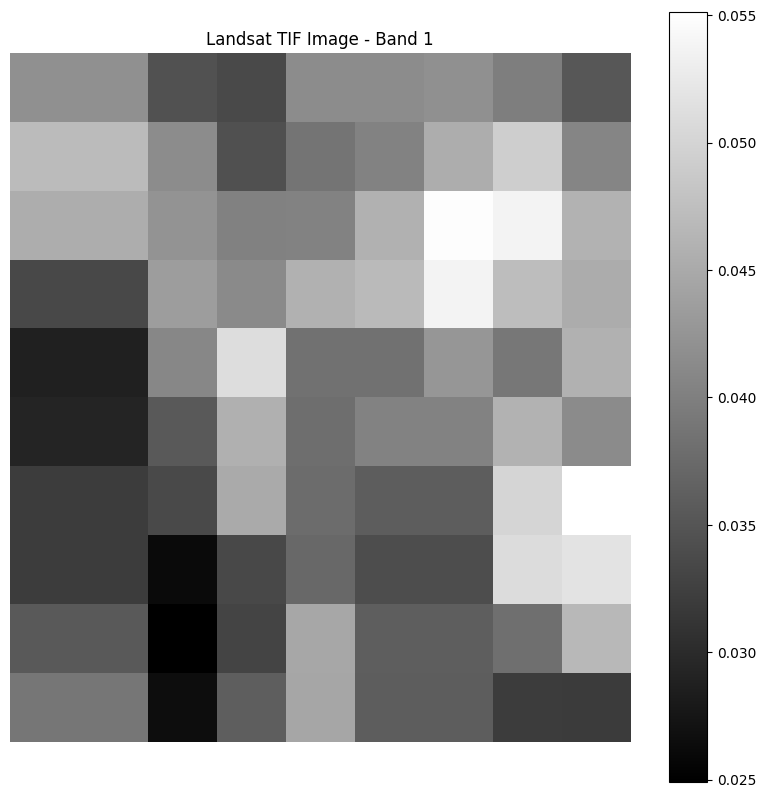

In [13]:
import rasterio
import matplotlib.pyplot as plt

# Path to your file
tif_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/landsat_train_-29901,13101.tif'

# Open and display the image
with rasterio.open(tif_path) as src:
    image = src.read(1)  # Read first band
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='gray')  # Change 'gray' to another colormap if needed
    plt.title("Landsat TIF Image - Band 1")
    plt.colorbar()
    plt.axis('off')
    plt.show()


target data

In [15]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import glob

# === File paths ===
csv_folder = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data/filtered_csvs'
grid_fp = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_Grid_with_Rand.geojson'
output_dir = os.path.join(csv_folder, 'with_splits')
os.makedirs(output_dir, exist_ok=True)

# === Load the annotated grid
grid_gdf = gpd.read_file(grid_fp)
assert 'rand' in grid_gdf.columns

# Add split column if not yet added
if 'split' not in grid_gdf.columns:
    def assign_split(rand):
        if rand < 0.6:
            return 'train'
        elif rand < 0.8:
            return 'val'
        else:
            return 'test'
    grid_gdf['split'] = grid_gdf['rand'].apply(assign_split)

# === Optional: buffer each polygon by ~10 meters to include boundary points
grid_gdf['geometry'] = grid_gdf.to_crs(epsg=3857).buffer(10).to_crs(epsg=4326)

print(f"Loaded grid with {len(grid_gdf)} tiles and CRS {grid_gdf.crs}")

# === Process each filtered GEDI CSV ===
csv_files = glob.glob(os.path.join(csv_folder, '*_filtered.csv'))

for csv_fp in csv_files:
    try:
        df = pd.read_csv(csv_fp)
        if df.empty:
            print(f"⚠️ Skipped empty: {csv_fp}")
            continue

        # Convert to GeoDataFrame
        gdf = gpd.GeoDataFrame(
            df,
            geometry=[Point(xy) for xy in zip(df['lon'], df['lat'])],
            crs='EPSG:4326'
        )

        # Spatial join with buffered grid using 'intersects'
        joined = gpd.sjoin(
            gdf,
            grid_gdf[['tile_id', 'split', 'geometry']],
            how='left',
            predicate='intersects'
        )

        # Drop points not matched to any tile
        joined = joined.dropna(subset=['split'])

        if joined.empty:
            print(f"⚠️ No matches for: {csv_fp}")
            continue

        # Output path
        out_fp = os.path.join(output_dir, os.path.basename(csv_fp).replace('_filtered.csv', '_filtered_with_split.csv'))

        # Save to CSV without geometry
        joined.drop(columns='geometry').to_csv(out_fp, index=False)
        print(f"✅ Saved: {out_fp}")

    except Exception as e:
        print(f"❌ Error processing {csv_fp}: {e}")


GEOSException: Shell empty after removing invalid points

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# # Define a small Conv block
# def conv_block(in_c, out_c):
#     return nn.Sequential(
#         nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#         nn.BatchNorm2d(out_c),
#         nn.ReLU(),
#         nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
#         nn.BatchNorm2d(out_c),
#         nn.ReLU(),
#     )

# # Each branch handles different resolutions
# class EOBranch(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.encoder = conv_block(in_channels, out_channels)

#     def forward(self, x, target_size):
#         x = self.encoder(x)
#         x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
#         return x

# class MultiResFusionModel(nn.Module):
#     def __init__(self, channel_dict):
#         super().__init__()
#         self.branches = nn.ModuleDict({
#             name: EOBranch(in_ch, 64) for name, in_ch in channel_dict.items()
#         })
#         self.fusion = conv_block(len(channel_dict) * 64, 128)
#         self.regressor = nn.Sequential(
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Flatten(),
#             nn.Linear(128, 1)
#         )

#     def forward(self, inputs):
#         target_size = inputs["s1"].shape[-2:]  # Assume s1 is highest resolution
#         feats = [branch(inputs[name], target_size) for name, branch in self.branches.items()]
#         fused = self.fusion(torch.cat(feats, dim=1))
#         return self.regressor(fused)

# # Example usage
# # Define input channel sizes
# channel_dict = {
#     "s1": 2,
#     "s2": 12,
#     "s2_idx": 5,
#     "landsat": 6,
#     "landsat_idx": 4,
#     "tcap": 3,
#     "hls": 5,
#     "dem": 3
# }

# model = MultiResFusionModel(channel_dict)
# example_input = {name: torch.randn(4, ch, 64 // (10 // res), 64 // (10 // res))
#                  for name, (ch, res) in zip(channel_dict.keys(),
#                                             [(channel_dict[k], 10 if 's1' in k or 's2' in k else 30)
#                                              for k in channel_dict])}

# out = model(example_input)
# print(out.shape)  # should be [B, 1]
